In [1]:
import pandas as pd
import numpy as np
from statsmodels.tsa.statespace.sarimax import SARIMAX
from pmdarima import auto_arima
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt
import os

In [2]:
df = pd.read_csv("clean_cyber.csv")  
df.head()

,Job Title,Company,Salary,Experience,Day Posted,Skills List,Location List
0,Cyber Security Analyst,Wipro,5.0,3,2022-01,Network Security,Hyderabad
1,Cyber Security Analyst,Wipro,5.0,3,2022-01,security operations,Hyderabad
2,Cyber Security Analyst,Wipro,5.0,3,2022-01,security assessment,Hyderabad
3,Cyber Security Analyst,Wipro,5.0,3,2022-01,information security,Hyderabad
4,Cyber Security Analyst,Wipro,5.0,3,2022-01,security monitoring,Hyderabad


In [3]:
df['Day Posted'] = pd.to_datetime(df['Day Posted'], errors='coerce')
df['year_month'] = df['Day Posted'].dt.to_period('M')

In [4]:
job_trend = df.groupby(['year_month', 'Job Title']).size().reset_index(name='job_count')

job_trend['year_month'] = job_trend['year_month'].astype(str)
job_trend['year_month'] = pd.to_datetime(job_trend['year_month'])

job_roles = job_trend['Job Title'].unique()

In [5]:
future_periods = 36

output_dir = "job_role_data"
os.makedirs(output_dir, exist_ok=True)

future_predictions = []
model_evaluation = []

Data for Cyber Security Analyst: 36 months
Performing stepwise search to minimize aic
 ARIMA(2,0,2)(1,0,1)[6] intercept   : AIC=524.839, Time=1.14 sec
 ARIMA(0,0,0)(0,0,0)[6] intercept   : AIC=538.239, Time=0.04 sec
 ARIMA(1,0,0)(1,0,0)[6] intercept   : AIC=536.503, Time=0.19 sec
 ARIMA(0,0,1)(0,0,1)[6] intercept   : AIC=534.897, Time=0.23 sec
 ARIMA(0,0,0)(0,0,0)[6]             : AIC=613.877, Time=0.06 sec
 ARIMA(2,0,2)(0,0,1)[6] intercept   : AIC=inf, Time=0.72 sec
 ARIMA(2,0,2)(1,0,0)[6] intercept   : AIC=525.210, Time=0.75 sec
 ARIMA(2,0,2)(2,0,1)[6] intercept   : AIC=inf, Time=1.03 sec
 ARIMA(2,0,2)(1,0,2)[6] intercept   : AIC=inf, Time=1.26 sec
 ARIMA(2,0,2)(0,0,0)[6] intercept   : AIC=inf, Time=0.23 sec
 ARIMA(2,0,2)(0,0,2)[6] intercept   : AIC=inf, Time=0.81 sec
 ARIMA(2,0,2)(2,0,0)[6] intercept   : AIC=521.351, Time=0.74 sec
 ARIMA(1,0,2)(2,0,0)[6] intercept   : AIC=518.636, Time=0.63 sec
 ARIMA(1,0,2)(1,0,0)[6] intercept   : AIC=525.893, Time=0.46 sec
 ARIMA(1,0,2)(2,0,1)[6] 

C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\statsmodels\tsa\base\tsa_model.py:471: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\statsmodels\tsa\base\tsa_model.py:471: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\statsmodels\tsa\statespace\sarimax.py:997: UserWarning: Non-stationary starting seasonal autoregressive Using zeros as starting parameters.
  warn('Non-stationary starting seasonal autoregressive'
C:\Users\DELL\AppData\Local\Temp\ipykernel_15820\464078182.py:38: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  forecast_index = pd.date_range(start=job_trend1.index[-1], periods=future_periods + 1, freq='M')[1:]



🔹 **Model Evaluation
📌 MAE  (Mean Absolute Error): 200.58
📌 MSE  (Mean Squared Error): 49628.39
📌 RMSE (Root Mean Squared Error): 222.77
📌 R²   (R-squared): 0.79
Saving predictions for Cyber Security Analyst to job_role_data/Cyber Security Analyst_predictions.csv
Saving location heatmap for Cyber Security Analyst to job_role_data/Cyber Security Analyst_location_heatmap.csv
Saving top 10 skills for Cyber Security Analyst to job_role_data/Cyber Security Analyst_top_skills.csv


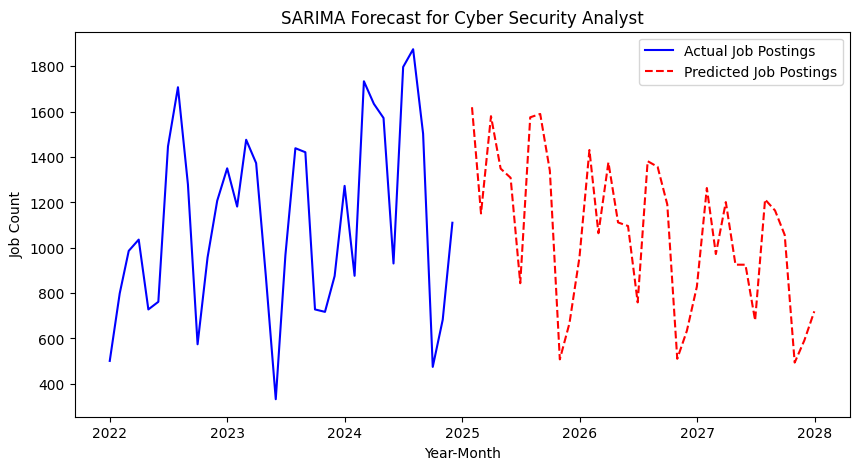


📊 Model Evaluation Summary:
                Job Title        MAE           MSE        RMSE        R2
0  Cyber Security Analyst  200.57731  49628.390086  222.774303  0.791376


In [ ]:
for job in job_roles:
    job_trend1 = job_trend[job_trend['Job Title'] == job].set_index('year_month')

    print(f"Data for {job}: {len(job_trend1)} months")

    # Ensure at least 24 months of data for SARIMA
    if len(job_trend1) < 24:
        print(f"Skipping {job} due to insufficient data.")
        continue

    #Apply Rolling Mean Smoothing (3-month window)
    job_trend1['job_count_smooth'] = job_trend1['job_count'].rolling(window=3, min_periods=1).mean()

    train_size = int(len(job_trend1) * 0.8)
    train, test = job_trend1.iloc[:train_size], job_trend1.iloc[train_size:]

    y = job_trend1['job_count_smooth']

    try:
        auto_model = auto_arima(y, 
                                seasonal=True, 
                                m=6,  #(half-yearly seasonality)
                                trace=True, 
                                suppress_warnings=True,
                                error_action='ignore')  

        best_order = auto_model.order
        best_seasonal_order = auto_model.seasonal_order
        print(f"\n🔹 Best SARIMA Order for {job}: {best_order}, Seasonal: {best_seasonal_order}")

        model = SARIMAX(y, 
                        order=best_order,  
                        seasonal_order=best_seasonal_order,  
                        enforce_invertibility=False)

        model_fit = model.fit(disp=False)

        forecast_index = pd.date_range(start=job_trend1.index[-1], periods=future_periods + 1, freq='M')[1:]
        forecast = model_fit.get_forecast(steps=future_periods).predicted_mean

        test_forecast = model_fit.get_prediction(start=test.index[0], end=test.index[-1]).predicted_mean
        mae = mean_absolute_error(test['job_count_smooth'], test_forecast)
        mse = mean_squared_error(test['job_count_smooth'], test_forecast)
        rmse = np.sqrt(mse)
        r2 = r2_score(test['job_count_smooth'], test_forecast)

        model_evaluation.append({'Job Title': job, 'MAE': mae, 'MSE': mse, 'RMSE': rmse, 'R2': r2})

        print(f"\n🔹 **Model Evaluation")
        print(f"📌 MAE  (Mean Absolute Error): {mae:.2f}")
        print(f"📌 MSE  (Mean Squared Error): {mse:.2f}")
        print(f"📌 RMSE (Root Mean Squared Error): {rmse:.2f}")
        print(f"📌 R²   (R-squared): {r2:.2f}")

        #Save Predictions to CSV
        predictions_df = pd.DataFrame({
            'year_month': forecast_index,
            'predicted_job_count': np.clip(forecast, 0, None),
            'job_title': job  
        })
        predictions_df.to_csv(f"{output_dir}/{job}_predictions.csv", index=False)
        print(f"Saving predictions for {job} to {output_dir}/{job}_predictions.csv")

        # Save Location Heatmap Data
        location_counts = df[df['Job Title'] == job]['Location List'].value_counts().reset_index()
        location_counts.columns = ['Location', 'Count']
        location_counts.to_csv(f"{output_dir}/{job}_location_heatmap.csv", index=False)
        print(f"Saving location heatmap for {job} to {output_dir}/{job}_location_heatmap.csv")

        # Save Top 10 Skills Data
        top_skills = df[df['Job Title'] == job]['Skills List'].str.split(',').explode().value_counts().head(10).reset_index()
        top_skills.columns = ['Skill', 'Count']
        top_skills.to_csv(f"{output_dir}/{job}_top_skills.csv", index=False)
        print(f"Saving top 10 skills for {job} to {output_dir}/{job}_top_skills.csv")

        # Add Predictions to future_predictions List
        future_predictions.append(predictions_df)

        # Plot Predictions
        plt.figure(figsize=(10, 5))
        plt.plot(job_trend1.index, job_trend1['job_count_smooth'], label='Actual Job Postings', color='blue')
        plt.plot(forecast_index, forecast, label='Predicted Job Postings', linestyle='dashed', color='red')
        plt.title(f'SARIMA Forecast for {job}')
        plt.xlabel("Year-Month")
        plt.ylabel("Job Count")
        plt.legend()
        plt.show()

    except Exception as e:
        print(f"Error processing {job}: {str(e)}")
        continue

# combine everything
if future_predictions: 
    future_predictions_df = pd.concat(future_predictions, ignore_index=True)
    model_evaluation_df = pd.DataFrame(model_evaluation)

    future_predictions_df.to_csv(f"{job}_future_job_forecast.csv", index=False)
    model_evaluation_df.to_csv("model_evaluation_metrics.csv", index=False)

    print("\n📊 Model Evaluation Summary:")
    print(model_evaluation_df)
else:
    print("No valid forecasts were generated. Check the data and model parameters.")